# Local UITI_VANO Interpretability

Notebook-first workflow for steps 1-3: circuit/date selection, deterministic critical-point detection, structured context, and optional LLM interpretation.

## 1. Setup and parameters

In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
import sys
from datetime import datetime, timezone
from pathlib import Path

try:
    from dotenv import load_dotenv
except ImportError:
    load_dotenv = None

# 1. Dynamically locate the project root by finding the 'src' directory
ROOT = Path.cwd().resolve()
while not (ROOT / "src").is_dir() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

# 2. Add 'src' to sys.path so Python can find project packages
src_path = str(ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# 3. Load environment variables. .env.example es solo plantilla; no se usa como credenciales activas.
if load_dotenv:
    _env_file = ROOT / ".env"
    if _env_file.exists():
        load_dotenv(_env_file)
        print(f"Config cargada desde: {_env_file.name}")
    else:
        print("Config .env no encontrada; se usará entorno del sistema u Ollama si está disponible.")

# 4. Import project modules
from chec_local_interpreter.attribution import enrich_critical_points
from chec_local_interpreter.config import CriticalityThresholds, DEFAULT_DATA_PATH, MAX_CRITICAL_POINTS as DEFAULT_MAX_CRITICAL_POINTS
from chec_local_interpreter.context_builder import build_context_package, critical_points_frame, save_json_artifact
from chec_local_interpreter.critical_points import build_daily_series, compute_daily_features, detect_critical_periods, detect_point_reasons, rank_critical_points
from chec_local_interpreter.expert_alignment import (
    cargar_discussiones_pdf_excel,
    construir_contexto_expert_alignment,
    construir_prompt_expert_alignment,
    extraer_fechas_informe,
    guardar_tabla_coincidencias_pdf,
    seleccionar_top_coincidencias_temporales,
    validar_respuesta_expert_alignment,
)
from chec_local_interpreter.data_loader import available_circuits, dataset_summary, filter_events, load_dataset, resolve_columns
from chec_local_interpreter.llm_client import call_llm, save_cot_html_graph
from chec_local_interpreter.llm_contracts import PROMPT_VERSION, load_output_schema, render_prompt, save_prompt_artifact
from chec_local_interpreter.llm_prompt import render_base_repair_prompt
from chec_local_interpreter.llm_skills import assemble_skill_bundle, list_available_skills, verify_required_skills
from chec_local_interpreter.llm_validation import save_invalid_output, validate_llm_response
from chec_local_interpreter.plotting import save_uiti_vano_plot, plot_interactive_critical_points
from chec_local_interpreter.web_export import export_plotly_figure_html

# =======================================================
# Configuración común elegida por el usuario
# =======================================================
DATA_PATH = str(ROOT / "data/Indicadores_vano_v3.csv")
SELECTED_CIRCUITOS = ["HER23L16"]
START_DATE = None  # Ej.: "2025-11-01 00:00:01"; None usa el inicio disponible.
END_DATE = None    # Ej.: "2026-04-30 21:53:40"; None usa el fin disponible.
MAX_CRITICAL_POINTS = 5
OUTPUT_DIR = ROOT / "reports" / "interpretability" / "artifacts"
CALL_LLM = True
PDF_DISCUSSIONS_EXCEL_PATH = ROOT / "reports" / "analysis-documents" / "tabla_pdfs_intervalo_2025-11-01_2026-04-30.xlsx"
TOP_K_PDF_DATE_MATCHES = 10
MAX_EXPERT_ROWS_FOR_LLM3 = 30
CALL_LLM3 = CALL_LLM
_configured_provider = os.getenv("LLM_PROVIDER")
if _configured_provider:
    LLM_PROVIDER = _configured_provider
elif os.getenv("GOOGLE_API_KEY", "").strip():
    LLM_PROVIDER = "google"
elif os.getenv("OPENAI_API_KEY", "").strip():
    LLM_PROVIDER = "openai"
else:
    LLM_PROVIDER = "ollama"

if LLM_PROVIDER.lower() == "ollama":
    LLM_MODEL = os.getenv("LLM_MODEL") or os.getenv("OLLAMA_MODEL", "deepseek-r1:32b")
elif LLM_PROVIDER.lower() == "openai":
    LLM_MODEL = os.getenv("LLM_MODEL", "gpt-4.1-mini")
else:
    LLM_MODEL = os.getenv("LLM_MODEL", "gemini-2.5-flash-lite")

LLM_MAX_OUTPUT_TOKENS = int(os.getenv("LLM_MAX_OUTPUT_TOKENS", "32768"))
LLM_BASE_MAX_OUTPUT_TOKENS = max(LLM_MAX_OUTPUT_TOKENS, int(os.getenv("LLM_BASE_MAX_OUTPUT_TOKENS", "65536")))
LLM_EXPERT_ALIGNMENT_MAX_OUTPUT_TOKENS = max(LLM_MAX_OUTPUT_TOKENS, int(os.getenv("LLM_EXPERT_ALIGNMENT_MAX_OUTPUT_TOKENS", "65536")))

# Fechas para los escenarios de inferencia. None usa los días de critical_points.
FECHAS_INTERES_USUARIO = None

# Parámetros MGCECDL / SHAP comunes a 8.1-8.7
# TOP_N_VANOS se interpreta como percentil: 97 => vanos con métrica >= P97.
TOP_VANOS_PERCENTILE = 97
# Esta misma regla alimenta la caracterización del circuito y el apartado 8.
TOP_N_VANOS = 97
TOP_K_VARS = 20
SHAP_BACKGROUND_SIZE = 40
SHAP_NSAMPLES = 80
SHAP_BATCH_SIZE = 512
SHAP_RANDOM_STATE = 42
FILTRO_UITI_MAX = None
VENTANA_CLIMATICA_HORAS = 12
VARIABLES_SELECCION_PATH = ROOT / "data" / "Variables_seleccion.xlsx"
OPTUNA_STUDY_PATH = ROOT / "data" / "optuna" / "mgcecdl_classification_feature_attention_params.journal"


def _modelo_mas_reciente(model_dir: Path, base_name: str) -> Path:
    stem = Path(base_name).stem
    suffix = Path(base_name).suffix
    candidates = sorted(model_dir.glob(f"{stem}*{suffix}"))
    if not candidates:
        raise FileNotFoundError(f"No encontrado: {base_name} en {model_dir}")
    selected = candidates[-1]
    if len(candidates) > 1:
        print(f"{len(candidates)} versiones de {base_name}. Usando: {selected.name}")
    return selected


MODEL_PATH = _modelo_mas_reciente(ROOT / "data" / "models", "mgcecdl_classifier_best.zip")


Config cargada desde: .env


## 2. Load data

In [2]:
import pandas as pd
raw_df = load_dataset(DATA_PATH)
column_resolution = resolve_columns(raw_df)
summary = dataset_summary(raw_df)
available = available_circuits(raw_df)
selected_label = SELECTED_CIRCUITOS if SELECTED_CIRCUITOS else "all circuits"
print(f"Dataset shape: {summary['shape']}")
print(f"Date range: {summary['date_min']} to {summary['date_max']}")
print(f"Available circuits: {summary['available_circuits_count']}")
print(f"Selected circuits parameter: {selected_label}")
print(f"Unavailable optional columns: {len(column_resolution.unavailable_optional)}")


Dataset shape: [159470, 273]
Date range: 2025-11-01 to 2026-04-30
Available circuits: 208
Selected circuits parameter: ['HER23L16']
Unavailable optional columns: 0


In [3]:
raw_df.head()

,CIRCUITO,FID_SW,COD_EQ_PROTEGE,FID_VANO,T_USUS_EQ_PROT,LVSW,CNT_VN,CNT_VN_SW,FECHA,DURACION,...,clouds_15,clouds_16,clouds_17,clouds_18,clouds_19,clouds_20,clouds_21,clouds_22,clouds_23,clouds_24
0,AGU23L14,20142930,AGU23L14,20139439,1821,2.568,16,22,2025-11-03 23:56:04,0.008,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1,AGU23L14,20142930,AGU23L14,20139439,1821,2.568,16,22,2025-11-18 17:08:14,0.008,...,100.0,100.0,84.0,99.0,99.0,98.0,98.0,97.0,98.0,100.0
2,AGU23L14,20142930,AGU23L14,20139439,1821,2.568,16,22,2025-11-19 20:25:50,0.008,...,79.0,99.0,100.0,100.0,100.0,97.0,100.0,100.0,99.0,98.0
3,AGU23L14,20142930,AGU23L14,20139439,1821,2.568,16,22,2025-12-10 21:33:41,0.008,...,69.0,93.0,100.0,55.0,61.0,32.0,56.0,59.0,58.0,76.0
4,AGU23L14,20142930,AGU23L14,20139439,1821,2.568,16,22,2025-12-19 15:59:10,0.041,...,99.0,97.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


## 2.1 Circuit Histograms: number of events and UITI

In [4]:
from chec_local_interpreter.plotting import plot_interactive_circuit_events

# =======================================================
# EJEMPLOS DE USO:
# =======================================================

# 1. Utilizar todo el intervalo de datos (sin filtrar)
fig = plot_interactive_circuit_events(raw_df)
fig.show()

# 2. Utilizar un intervalo de fechas específico
#fig = plot_interactive_circuit_events(raw_df, start_date='2025-11-01 00:00:01', end_date='2025-12-01 00:00:01')
#fig.show()


In [5]:
from chec_local_interpreter.plotting import plot_interactive_uiti_vano_sums

# =======================================================
# EJEMPLOS DE USO:
# =======================================================

# 1. Utilizar todo el intervalo de datos (sin filtrar)
fig_sums = plot_interactive_uiti_vano_sums(raw_df)
fig_sums.show()

# 2. Utilizar un intervalo de fechas específico
# fig_sums = plot_interactive_uiti_vano_sums(raw_df, start_date='2025-11-01 00:00:01', end_date='2025-12-01 00:00:01')
# fig_sums.show()


In [6]:
from chec_local_interpreter.plotting import run_kmeans, plot_interactive_circuit_clustering

# Destaca el circuito o circuitos definidos al inicio del notebook.
circuitos_destacados = SELECTED_CIRCUITOS or []

fig_cluster = plot_interactive_circuit_clustering(
    raw_df,
    highlighted_circuits=circuitos_destacados,
    start_date=START_DATE,
    end_date=END_DATE,
)
fig_cluster.show()


## 2.2 GIS MAP

In [7]:
from chec_local_interpreter.plotting import plot_circuit_map_plotly

if SELECTED_CIRCUITOS:
    CIRCUITO_MAPA_INTERES = SELECTED_CIRCUITOS[0]
else:
    disponibles_mapa = available_circuits(raw_df)
    if not disponibles_mapa:
        raise ValueError("No hay circuitos disponibles para construir el mapa.")
    CIRCUITO_MAPA_INTERES = disponibles_mapa[0]

fig_circuit_map = plot_circuit_map_plotly(
    df=raw_df,
    circuito_name=CIRCUITO_MAPA_INTERES,
    date_range=(START_DATE, END_DATE) if START_DATE or END_DATE else None,
    color_target='number_of_events',
)
fig_circuit_map.show()
site_circuit_map_path = export_plotly_figure_html(fig_circuit_map, "base_circuit_map.html")
print(f"Mapa web actualizado: {site_circuit_map_path.name}")


Mapa web actualizado: base_circuit_map.html


In [8]:
plot_circuit_map_plotly(
    df=raw_df,
    circuito_name=CIRCUITO_MAPA_INTERES,
    date_range=(START_DATE, END_DATE) if START_DATE or END_DATE else None,
    color_target='UITI_VANO_sum',
)


## 3. Filter dataset

In [9]:
timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = str((ROOT / DATA_PATH).resolve() if not Path(DATA_PATH).is_absolute() else Path(DATA_PATH))
DATA_PATH


'/Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/data/Indicadores_vano_v3.csv'

In [10]:
events_df = filter_events(
    raw_df,
    selected_circuitos=SELECTED_CIRCUITOS,
    start_date=START_DATE,
    end_date=END_DATE,
)
selected_circuitos_effective = SELECTED_CIRCUITOS or sorted(events_df['CIRCUITO'].dropna().astype(str).unique().tolist())
start_effective = START_DATE or (events_df['fecha_dia'].min().date().isoformat() if not events_df.empty else None)
end_effective = END_DATE or (events_df['fecha_dia'].max().date().isoformat() if not events_df.empty else None)
print(f"Filtered rows: {len(events_df)}")
print(f"Effective circuits: {selected_circuitos_effective[:10]}{' ...' if len(selected_circuitos_effective) > 10 else ''}")
print(f"Effective window: {start_effective} to {end_effective}")

Filtered rows: 4856
Effective circuits: ['HER23L16']
Effective window: 2025-11-05 to 2026-04-30


In [11]:
events_df.head()

,CIRCUITO,FID_SW,COD_EQ_PROTEGE,FID_VANO,T_USUS_EQ_PROT,LVSW,CNT_VN,CNT_VN_SW,FECHA,DURACION,...,clouds_16,clouds_17,clouds_18,clouds_19,clouds_20,clouds_21,clouds_22,clouds_23,clouds_24,fecha_dia
12941,HER23L16,357288136,REC0016,20606585,1715,3.892,31,53,2025-11-25 15:50:18,0.001,...,91.0,95.0,100.0,99.0,100.0,100.0,98.0,100.0,100.0,2025-11-25
12942,HER23L16,357288136,REC0016,20606585,1715,3.892,31,53,2025-12-01 20:28:34,0.001,...,75.0,71.0,94.0,88.0,95.0,99.0,100.0,100.0,100.0,2025-12-01
12943,HER23L16,357288136,REC0016,20606585,1715,3.892,31,53,2025-12-16 15:05:15,0.001,...,54.0,99.0,98.0,98.0,91.0,100.0,76.0,73.0,84.0,2025-12-16
12944,HER23L16,357288136,REC0016,20606585,1715,3.892,31,53,2026-01-01 20:42:52,0.028,...,98.0,98.0,99.0,99.0,98.0,98.0,99.0,98.0,97.0,2026-01-01
12945,HER23L16,357288136,REC0016,20606585,1715,3.892,31,53,2026-01-01 21:35:34,0.001,...,97.0,98.0,98.0,99.0,99.0,98.0,98.0,99.0,98.0,2026-01-01


## 4. Build daily UITI_VANO series

In [12]:
daily_df = build_daily_series(events_df)
display(daily_df.head())
print(f"Daily rows: {len(daily_df)}")
print(f"Total UITI_VANO: {daily_df['UITI_VANO'].sum() if not daily_df.empty else 0}")

,fecha_dia,UITI_VANO,event_count,DURACION_total,users_total,UITI,DURACION_available,users_available,UITI_available
0,2025-11-05,69472.725160,190,529.511,241566,113648.956,True,True,True
1,2025-11-06,0.000000,0,0.000,0,0.000,False,False,False
2,2025-11-07,80656.728170,52,147.992,56004,159368.092,True,True,True
3,2025-11-08,0.000000,0,0.000,0,0.000,False,False,False
4,2025-11-09,12.216601,5,22.750,5,22.750,True,True,True


Daily rows: 177
Total UITI_VANO: 507228.42400245793


In [13]:
daily_df['event_count'].sum()

np.int64(4856)

## 5. Detect relevant/critical points

In [14]:
thresholds = CriticalityThresholds(max_points=MAX_CRITICAL_POINTS)
feature_df = compute_daily_features(daily_df, metric="UITI_VANO")
reasons = detect_point_reasons(feature_df, thresholds=thresholds, metric="UITI_VANO")
critical_points = rank_critical_points(feature_df, reasons, max_points=MAX_CRITICAL_POINTS, metric="UITI_VANO")
critical_periods = detect_critical_periods(feature_df, thresholds=thresholds, metric="UITI_VANO")
display(critical_points_frame(critical_points))
critical_periods

,critical_point_id,fecha_dia,rank,score,types,selection_reason,UITI_VANO,events
0,cp-2026-03-02,2026-03-02,1,5.60,high_robust_z;local_peak;sharp_positive_change...,UITI_VANO esta por encima de la linea base rob...,81242.6,470
1,cp-2025-11-07,2025-11-07,2,5.57,high_robust_z;local_peak;sharp_positive_change...,UITI_VANO esta por encima de la linea base rob...,80656.7,52
2,cp-2026-03-30,2026-03-30,3,3.91,high_robust_z;local_peak;sharp_positive_change...,UITI_VANO esta por encima de la linea base rob...,54135.0,390
3,cp-2025-11-05,2025-11-05,4,3.44,high_robust_z;top_contribution_day,UITI_VANO esta por encima de la linea base rob...,69472.7,190
4,cp-2026-03-11,2026-03-11,5,2.62,high_robust_z;local_peak;sharp_positive_change,UITI_VANO esta por encima de la linea base rob...,49999.8,458


[{'critical_period_id': 'period-2026-04-19-2026-04-21',
  'start_date': '2026-04-19',
  'end_date': '2026-04-21',
  'days': 3,
  'period_type': 'sustained_elevated_uiti_vano',
  'score': 0.0063,
  'total_uiti_vano': 3189.6191,
  'summary': 'UITI_VANO permanecio elevado durante 3 dias entre 2026-04-19 y 2026-04-21.'}]

## 6. Enrich critical points

In [15]:
critical_points = enrich_critical_points(events_df, critical_points)
print(f"Enriched critical points: {len(critical_points)}")
critical_points[:1]

Enriched critical points: 5


[{'critical_point_id': 'cp-2026-03-02',
  'fecha_dia': '2026-03-02',
  'score': 5.6,
  'types': ['high_robust_z',
   'local_peak',
   'sharp_positive_change',
   'top_contribution_day'],
  'selection_reason': 'UITI_VANO esta por encima de la linea base robusta de la ventana. UITI_VANO sube bruscamente frente al dia anterior.',
  'metrics': {'UITI_VANO': 81242.6,
   'z': 6.8,
   'delta': 81242.6,
   'contrib': 0.1602},
  'daily_aggregates': {'events': 470, 'dur': 191.3, 'users': 855909.0},
  'rank': 1,
  'attr': {'causes': [{'Apertura Por Falla Del Transfo': 443},
    {'Apertura Por Condiciones Atmos': 27}],
   'vanos': [{'20606847': 5}, {'20606813': 5}, {'20606891': 5}],
   'top_rows': [{'FID_VANO': '20606847',
     'DESC_CAUSA': 'Apertura Por Falla Del Transformador De Potencia Y Equipos Asociados.',
     'UITI_VANO': '1672.663'},
    {'FID_VANO': '20606813',
     'DESC_CAUSA': 'Apertura Por Falla Del Transformador De Potencia Y Equipos Asociados.',
     'UITI_VANO': '1649.29245908183

In [16]:
fig_critical = plot_interactive_critical_points(
    daily_df,
    critical_points,
    selected_circuitos=selected_circuitos_effective,
    start_date=start_effective,
    end_date=end_effective,
)
fig_critical.show()
site_critical_points_path = export_plotly_figure_html(fig_critical, "base_critical_points.html")
print(f"Puntos críticos web actualizados: {site_critical_points_path.name}")


Puntos críticos web actualizados: base_critical_points.html


## 7. Build structured context JSON

In [17]:
context_package = build_context_package(
    raw_df=raw_df,
    events_df=events_df,
    daily_df=daily_df,
    critical_points=critical_points,
    critical_periods=critical_periods,
    selected_circuitos=selected_circuitos_effective,
    start_date=start_effective,
    end_date=end_effective,
    top_vanos_percentile=TOP_N_VANOS,
)
print(json.dumps({
    'analysis_name': context_package['analysis_name'],
    'selected_context': context_package['selected_context'],
    'summary': context_package['summary'],
    'critical_point_count': len(context_package['critical_points']),
}, ensure_ascii=False, indent=2))

{
  "analysis_name": "local_uiti_vano_interpretability",
  "selected_context": {
    "circuitos": [
      "HER23L16"
    ],
    "indicator": "UITI_VANO",
    "characterization": [
      {
        "circuito": "HER23L16",
        "criticidad": "Muy Alta",
        "eventos": 4856,
        "uiti_vano_total": 507228.0,
        "avg_eventos_red": 767.0,
        "avg_uiti_red": 84890.0,
        "top_vanos_percentile": 97.0,
        "p97_uiti": [
          "20606748(U:11728)",
          "39918635(U:11255)",
          "20607032(U:10610)",
          "39920587(U:9641)",
          "39920585(U:9064)"
        ],
        "p97_eventos": [
          "20606653(E:51.0)",
          "20607137(E:51.0)",
          "39920587(E:51.0)",
          "39920585(E:51.0)",
          "39920583(E:51.0)"
        ]
      }
    ]
  },
  "summary": {
    "events": 4856,
    "nonzero_days": 53,
    "total_uv": 507228.42,
    "max_date": "2026-03-02",
    "max_uv": 81242.65
  },
  "critical_point_count": 5
}


## 8. Inferencias MGCECDL — análisis de variables por circuito

Escenarios de atribución usando Kernel SHAP sobre el modelo MGCECDL de inferencia:

1. **Top-97 por UITI_VANO** — período completo.
2. **Top-97 por frecuencia** — período completo.
3. **Top-97 por UITI_VANO** — puntos críticos derivados automáticamente.
4. **Top-97 por frecuencia** — puntos críticos derivados automáticamente.

Cada escenario conserva el grafo interactivo estimado por reconstrucción MGCECDL + RBF y lo entrega al agente de inferencia.

In [18]:
# Conexión con la configuración común y con los puntos críticos detectados.
CIRCUITO_INTERES = selected_circuitos_effective[0]
FECHA_INICIO = str(start_effective)
FECHA_FIN = str(end_effective)
FECHAS_INTERES = (
    list(FECHAS_INTERES_USUARIO)
    if FECHAS_INTERES_USUARIO is not None
    else [cp["fecha_dia"] for cp in critical_points]
)

print(f"Circuito       : {CIRCUITO_INTERES}")
print(f"Período        : {FECHA_INICIO}  →  {FECHA_FIN}")
print(f"Fechas críticas: {FECHAS_INTERES}")

Circuito       : HER23L16
Período        : 2025-11-05  →  2026-04-30
Fechas críticas: ['2026-03-02', '2025-11-07', '2026-03-30', '2025-11-05', '2026-03-11']


In [19]:
# Rutas requeridas por el flujo MGCECDL.
for _p in [VARIABLES_SELECCION_PATH, MODEL_PATH]:
    if not _p.exists():
        raise FileNotFoundError(f"No encontrado: {_p}")

print(f"Modelo MGCECDL : {MODEL_PATH}")
print(f"Percentil vanos: P{TOP_N_VANOS}")
print(f"Top-K variables: {TOP_K_VARS}")
print(f"SHAP background: {SHAP_BACKGROUND_SIZE}")
print(f"SHAP nsamples  : {SHAP_NSAMPLES}")
print(f"Filtro UITI max: {FILTRO_UITI_MAX}")
print(f"Ventana clima  : {VENTANA_CLIMATICA_HORAS} horas")

Modelo MGCECDL : /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/data/models/mgcecdl_classifier_best.zip
Percentil vanos: P97
Top-K variables: 20
SHAP background: 40
SHAP nsamples  : 80
Filtro UITI max: None
Ventana clima  : 12 horas


### 8.1 Carga, preprocesamiento y escalado MGCECDL

`procesar_dataset_completo` construye la matriz de features; luego se aplica el mismo escalado min-max usado por el entrenamiento MGCECDL antes de filtrar circuito y período.

In [20]:
import io
import warnings
from contextlib import redirect_stdout

import numpy as np
from chec_impacto.data import preparar_splits_estratificados, procesar_dataset_completo
from chec_impacto.training import escalar_features_minmax_mgcecdl, resolve_training_device

DEVICE = resolve_training_device("auto")
print(f"Usando device: {DEVICE}")

with redirect_stdout(io.StringIO()):
    datos_inferencia = procesar_dataset_completo(
        path_clima=DATA_PATH,
        path_variables_seleccion=VARIABLES_SELECCION_PATH,
        use_sampling=False,
        min_samples_per_codigo=5,
        target="UITI_VANO",
        filtro_uiti_max=FILTRO_UITI_MAX,
        ventana_climatica_horas=VENTANA_CLIMATICA_HORAS,
    )

X_full_raw = np.asarray(datos_inferencia["X"], dtype=np.float32)
features = list(datos_inferencia["features"])
base_full = datos_inferencia["df_original_copy"].copy().reset_index(drop=True)

splits_clf = escalar_features_minmax_mgcecdl(
    preparar_splits_estratificados(
        X_full_raw,
        datos_inferencia["y"],
        modo="clasificacion",
        random_state=SHAP_RANDOM_STATE,
    )
)
feature_scaler = splits_clf["feature_scaler"]
X_full = feature_scaler.transform(X_full_raw).astype(np.float32)

fechas_col_inf = pd.to_datetime(base_full["FECHA"], errors="coerce")
mascara_inf = (
    base_full["CIRCUITO"].astype(str).str.strip().eq(CIRCUITO_INTERES)
    & fechas_col_inf.ge(pd.Timestamp(FECHA_INICIO))
    & fechas_col_inf.le(pd.Timestamp(FECHA_FIN))
)
if not mascara_inf.any():
    raise ValueError(f"Sin datos de inferencia para {CIRCUITO_INTERES} entre {FECHA_INICIO} y {FECHA_FIN}.")

X_inf = X_full[mascara_inf.to_numpy()]
base_inf = base_full[mascara_inf].copy().reset_index(drop=True)
base_inf["_FECHA_DIA"] = fechas_col_inf[mascara_inf].dt.strftime("%Y-%m-%d").values

print(f"Eventos      : {len(X_inf):,}")
print(f"Vanos únicos : {base_inf['FID_VANO'].nunique():,}")
print(f"Features     : {len(features)}")

Usando device: mps
Dataset original: X=(159470, 70), y=(159470, 1)
Splits generados -> Train: (102060, 70), Valid: (25516, 70), Test: (31894, 70)
Modo objetivo: clasificacion

Distribución de clases para estratificación:
Original: [39868 39867 39867 39868]
Train:    [25515 25515 25515 25515]
Valid:    [6379 6379 6379 6379]
Test:     [7974 7973 7973 7974]
Eventos      : 4,825
Vanos únicos : 470
Features     : 70


### 8.2 Modelo MGCECDL y Kernel SHAP

In [21]:
from chec_impacto.training import cargar_estudio_optuna_mgcecdl, cargar_modelo_mgcecdl, predict_classification

with warnings.catch_warnings(), redirect_stdout(io.StringIO()):
    warnings.simplefilter("ignore")
    modelo_inferencia = cargar_modelo_mgcecdl(str(MODEL_PATH), device=DEVICE)

if OPTUNA_STUDY_PATH.exists():
    study_clf = cargar_estudio_optuna_mgcecdl(OPTUNA_STUDY_PATH, "clasificacion")
    GRAFO_ESTIMADO_RBF_SIGMA = float(study_clf.best_params.get("rbf_sigma", 1.0))
else:
    warnings.warn(
        f"No existe {OPTUNA_STUDY_PATH}; se usará rbf_sigma=1.0 para el grafo estimado.",
        RuntimeWarning,
    )
    GRAFO_ESTIMADO_RBF_SIGMA = 1.0

print(f"Modelo: {type(modelo_inferencia).__name__} | {MODEL_PATH.name}")
print(f"rbf_sigma para grafo estimado: {GRAFO_ESTIMADO_RBF_SIGMA}")

Modelo: MGCECDLClassifier | mgcecdl_classifier_best.zip
rbf_sigma para grafo estimado: 4.668017104669593


In [22]:
from chec_impacto.interpretability.circuit_analysis import KernelShapTopVarsExtractor


class MGCECDLClassifierShapAdapter:
    """Adaptador predict_proba para reutilizar Kernel SHAP con MGCECDL."""

    def __init__(self, model, device):
        self.model = model
        self.device = device

    def predict_proba(self, values):
        values = np.asarray(values, dtype=np.float32)
        if values.ndim == 1:
            values = values.reshape(1, -1)
        return np.asarray(
            predict_classification(self.model, values, device=self.device)["fused_probs"],
            dtype=np.float64,
        )


modelo_shap = MGCECDLClassifierShapAdapter(modelo_inferencia, DEVICE)
shap_extractor = KernelShapTopVarsExtractor(
    model=modelo_shap,
    X=X_inf,
    features=features,
    top_k=TOP_K_VARS,
    background_size=SHAP_BACKGROUND_SIZE,
    nsamples=SHAP_NSAMPLES,
    batch_size=SHAP_BATCH_SIZE,
    random_state=SHAP_RANDOM_STATE,
)
print(
    f"Kernel SHAP configurado | fondo={shap_extractor.n_background} "
    f"| nsamples={SHAP_NSAMPLES} | batch={SHAP_BATCH_SIZE}"
)

Kernel SHAP configurado | fondo=40 | nsamples=80 | batch=512


### 8.3 Configuración de escenarios, modos y grafos

In [23]:
from chec_impacto.interpretability.circuit_analysis import (
    agrupar_por_vano,
    construir_contexto_escenario_inferencia,
    construir_contexto_inferencia,
    construir_modos_chec,
    construir_prompt_inferencia,
    graficar_barras_y_radar,
    validar_respuesta_inferencia,
)


def seleccionar_vanos_por_percentil(tabla, metric_col, percentile):
    """Selecciona vanos con metric_col >= percentil configurado."""
    if tabla.empty:
        return tabla.copy(), float("nan")
    p = min(max(float(percentile), 0.0), 100.0)
    values = pd.to_numeric(tabla[metric_col], errors="coerce").fillna(0.0)
    threshold = float(values.quantile(p / 100.0))
    selected = tabla[values >= threshold].copy()
    selected = selected.sort_values([metric_col, "UITI_VANO_PROM"], ascending=[False, False], kind="stable")
    return selected.reset_index(drop=True), threshold


def etiqueta_top_percentil():
    p = int(TOP_N_VANOS) if float(TOP_N_VANOS).is_integer() else TOP_N_VANOS
    return f"P{p}"

MODOS = construir_modos_chec(features, VARIABLES_SELECCION_PATH)
tabla_periodo_inf = agrupar_por_vano(base_inf)
inference_results = {}
TOP_VANOS_LABEL = etiqueta_top_percentil()

GRAPH_OUTPUT_DIR = ROOT / "reports" / "mgcecdl-results" / "interactive_graphs"
GRAPH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Modos          : {len(MODOS)}")
print(f"Vanos período  : {len(tabla_periodo_inf)} | Percentil análisis: {TOP_VANOS_LABEL}")
print(f"Grafos HTML    : {GRAPH_OUTPUT_DIR}")


Modos          : 6
Vanos período  : 470 | Percentil análisis: P97
Grafos HTML    : /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/mgcecdl-results/interactive_graphs


In [24]:
def ejecutar_escenario_inferencia(
    key,
    nombre,
    criterio,
    tabla_top,
    eventos_escenario,
    graph_output_name,
    fechas_interes=None,
):
    resultado = graficar_barras_y_radar(
        eventos_escenario,
        nombre,
        circuito=CIRCUITO_INTERES,
        features=features,
        modos=MODOS,
        shap_extractor=shap_extractor,
        top_k=TOP_K_VARS,
        graph_source="estimated",
        estimated_graph_model=modelo_inferencia,
        X_model=X_inf,
        estimated_graph_rbf_sigma=GRAFO_ESTIMADO_RBF_SIGMA,
        estimated_graph_device=DEVICE,
        estimated_graph_batch_size=SHAP_BATCH_SIZE,
        graph_output_dir=GRAPH_OUTPUT_DIR,
        graph_output_name=graph_output_name,
    )
    resultado["contexto"] = construir_contexto_escenario_inferencia(
        nombre=nombre,
        criterio=criterio,
        resultado=resultado,
        tabla_top=tabla_top,
        modos=MODOS,
        top_k=TOP_K_VARS,
        fechas_interes=fechas_interes,
        ventana_climatica_horas=VENTANA_CLIMATICA_HORAS,
    )
    inference_results[key] = resultado
    return resultado

### 8.4 Top-97 por UITI_VANO — período completo

P97 UITI_VANO período: umbral >= 1558.995 | vanos seleccionados: 15
Top P97 por UITI_VANO — período completo | eventos: 15 | vanos: 15


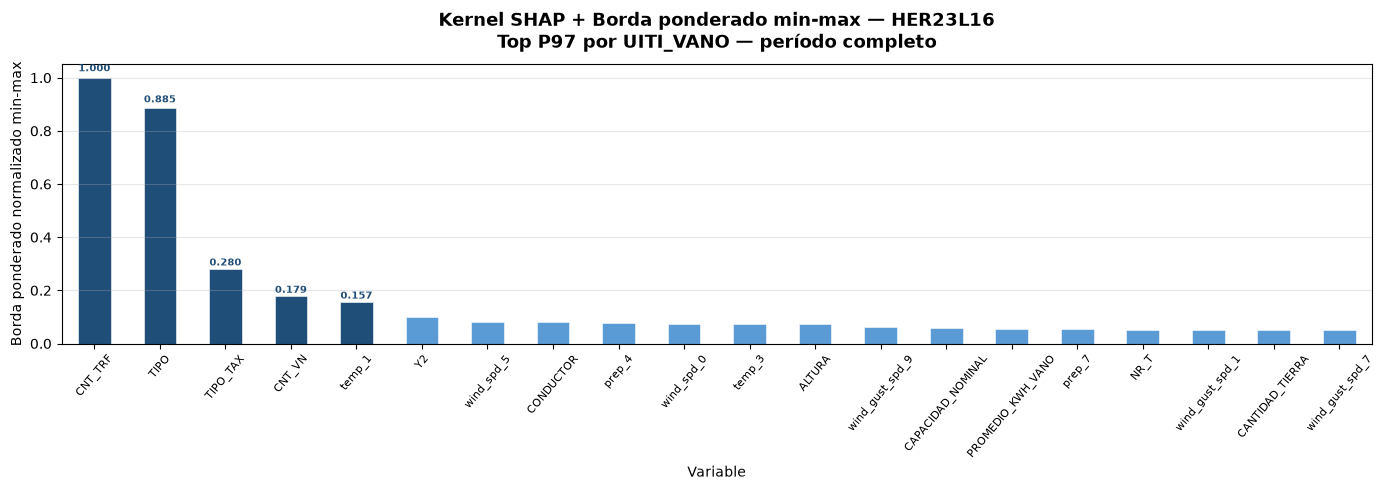

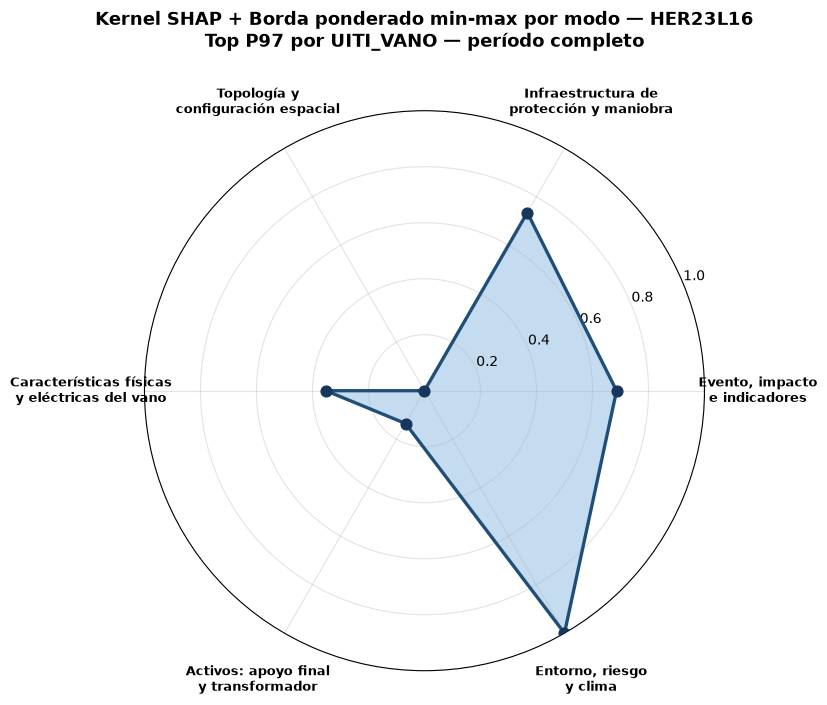

Grafo interactivo guardado en: /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/mgcecdl-results/interactive_graphs/top_uiti_periodo.html


In [25]:
tabla_top_uiti, threshold_uiti_periodo = seleccionar_vanos_por_percentil(
    tabla_periodo_inf,
    "UITI_VANO_PROM",
    TOP_N_VANOS,
)
ids_top_uiti = tabla_top_uiti["FID_VANO"].tolist()
base_top_uiti = base_inf[base_inf["FID_VANO"].isin(ids_top_uiti)].copy()

print(
    f"{TOP_VANOS_LABEL} UITI_VANO período: umbral >= {threshold_uiti_periodo:.3f} | "
    f"vanos seleccionados: {len(tabla_top_uiti)}"
)

resultado_top_uiti = ejecutar_escenario_inferencia(
    key="top_uiti_periodo",
    nombre=f"Top {TOP_VANOS_LABEL} por UITI_VANO — período completo",
    criterio=f"seleccionar vanos con UITI_VANO_PROM >= percentil {TOP_N_VANOS} del período completo",
    tabla_top=tabla_top_uiti,
    eventos_escenario=base_top_uiti,
    graph_output_name="top_uiti_periodo.html",
)


### 8.5 Top-97 por frecuencia — período completo

P97 frecuencia período: umbral >= 51.000 | vanos seleccionados: 19 | solapamiento UITI/frecuencia: 0
Top P97 por frecuencia — período completo | eventos: 969 | vanos: 19


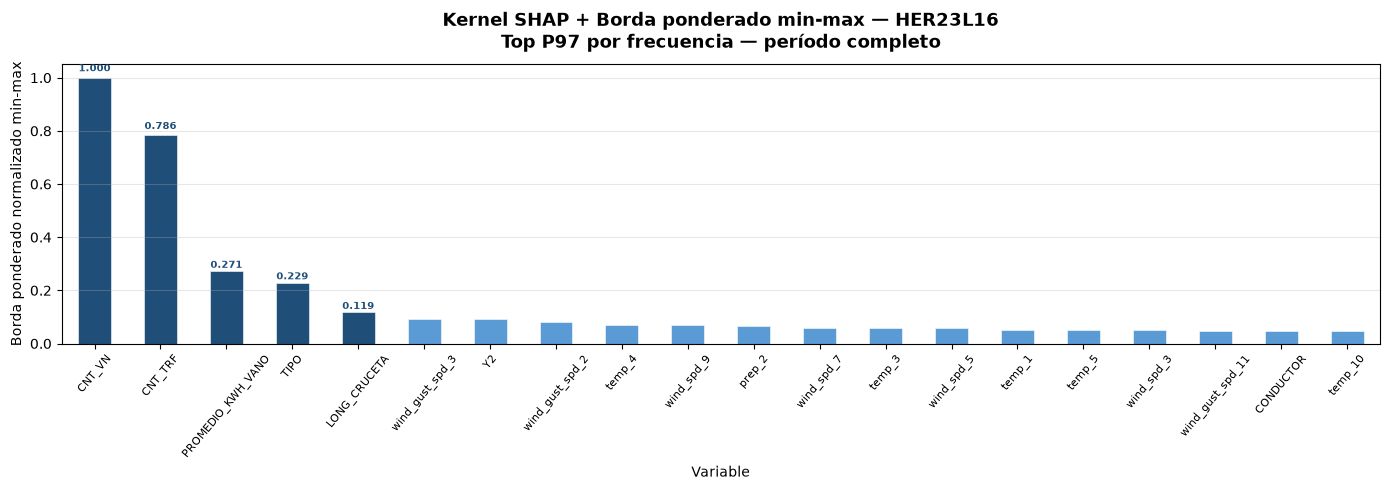

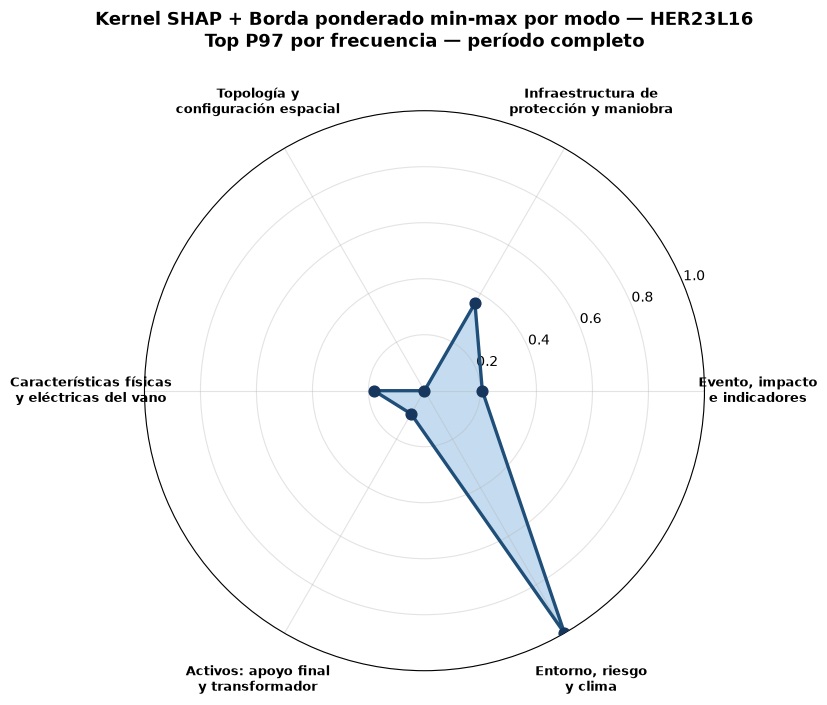

Grafo interactivo guardado en: /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/mgcecdl-results/interactive_graphs/top_frecuencia_periodo.html


In [26]:
tabla_top_frecuencia, threshold_frecuencia_periodo = seleccionar_vanos_por_percentil(
    tabla_periodo_inf,
    "N_APARICIONES",
    TOP_N_VANOS,
)
ids_top_frecuencia = tabla_top_frecuencia["FID_VANO"].tolist()
base_top_frecuencia = base_inf[base_inf["FID_VANO"].isin(ids_top_frecuencia)].copy()

overlap_periodo = len(set(ids_top_uiti).intersection(ids_top_frecuencia))
print(
    f"{TOP_VANOS_LABEL} frecuencia período: umbral >= {threshold_frecuencia_periodo:.3f} | "
    f"vanos seleccionados: {len(tabla_top_frecuencia)} | "
    f"solapamiento UITI/frecuencia: {overlap_periodo}"
)

resultado_top_frecuencia = ejecutar_escenario_inferencia(
    key="top_frecuencia_periodo",
    nombre=f"Top {TOP_VANOS_LABEL} por frecuencia — período completo",
    criterio=f"seleccionar vanos con N_APARICIONES >= percentil {TOP_N_VANOS} del período completo; UITI_VANO_PROM solo ordena empates",
    tabla_top=tabla_top_frecuencia,
    eventos_escenario=base_top_frecuencia,
    graph_output_name="top_frecuencia_periodo.html",
)


### 8.6 Top-97 — puntos críticos

Las fechas se derivan automáticamente de `critical_points`. Se calculan dos lecturas: gravedad (`UITI_VANO_PROM`) y número de eventos (`N_APARICIONES`).

P97 UITI_VANO puntos críticos: umbral >= 1923.773 | vanos seleccionados: 8
Top P97 por UITI_VANO — puntos críticos (2026-03-02, 2025-11-07, 2026-03-30, 2025-11-05, 2026-03-11) | eventos: 8 | vanos: 8


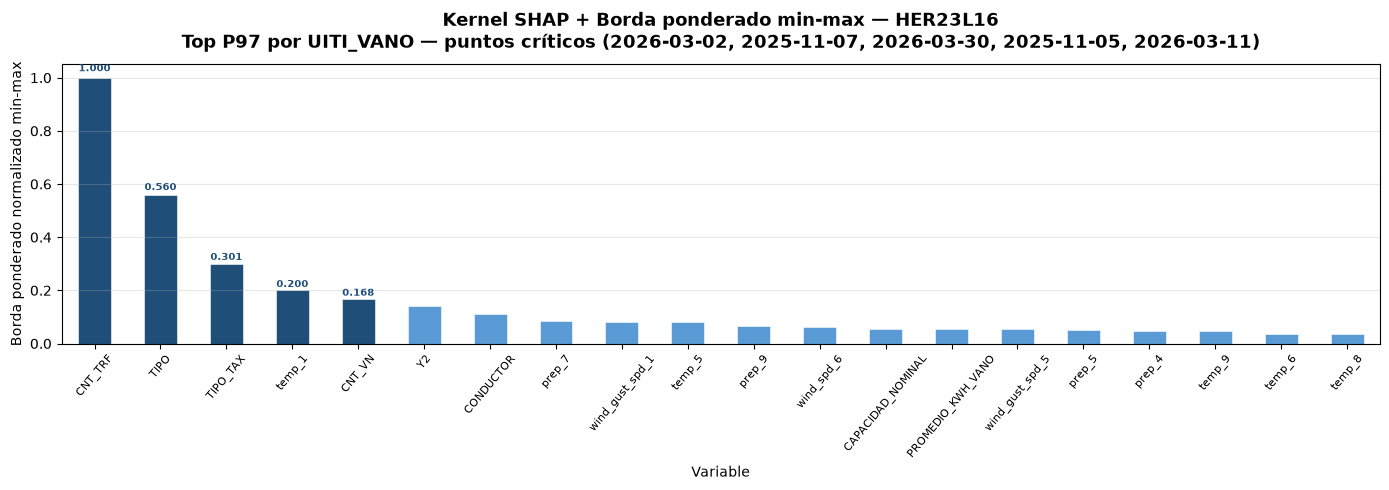

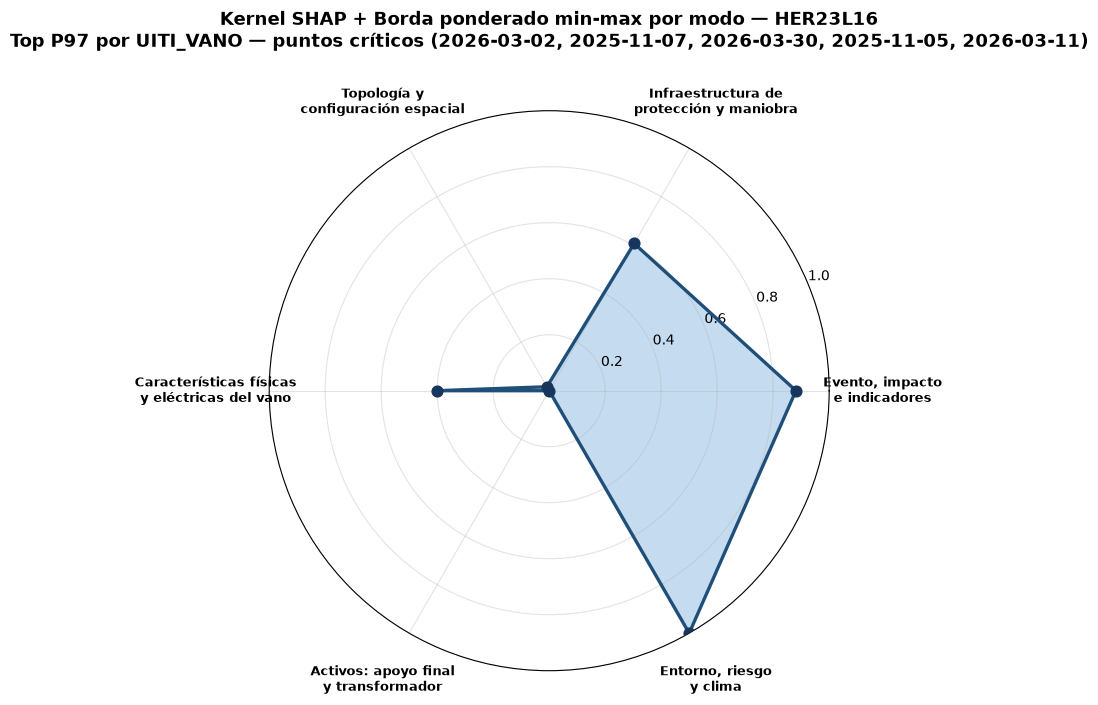

Grafo interactivo guardado en: /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/mgcecdl-results/interactive_graphs/top_uiti_fechas.html
P97 frecuencia puntos críticos: umbral >= 13.000 | vanos seleccionados: 52 | solapamiento UITI/frecuencia: 0
Top P97 por frecuencia — puntos críticos (2026-03-02, 2025-11-07, 2026-03-30, 2025-11-05, 2026-03-11) | eventos: 676 | vanos: 52


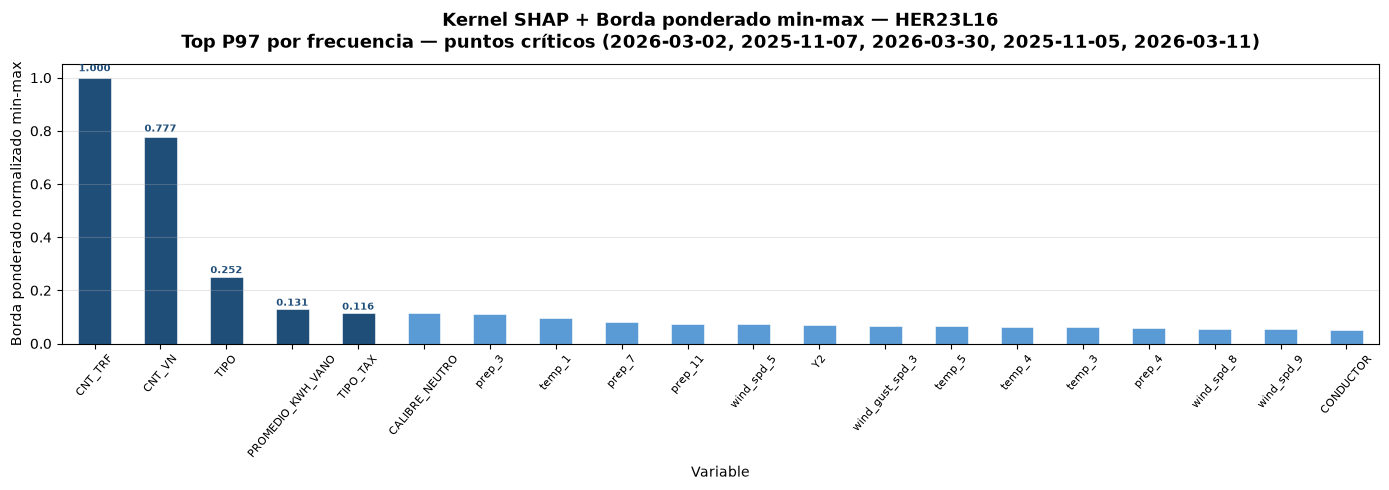

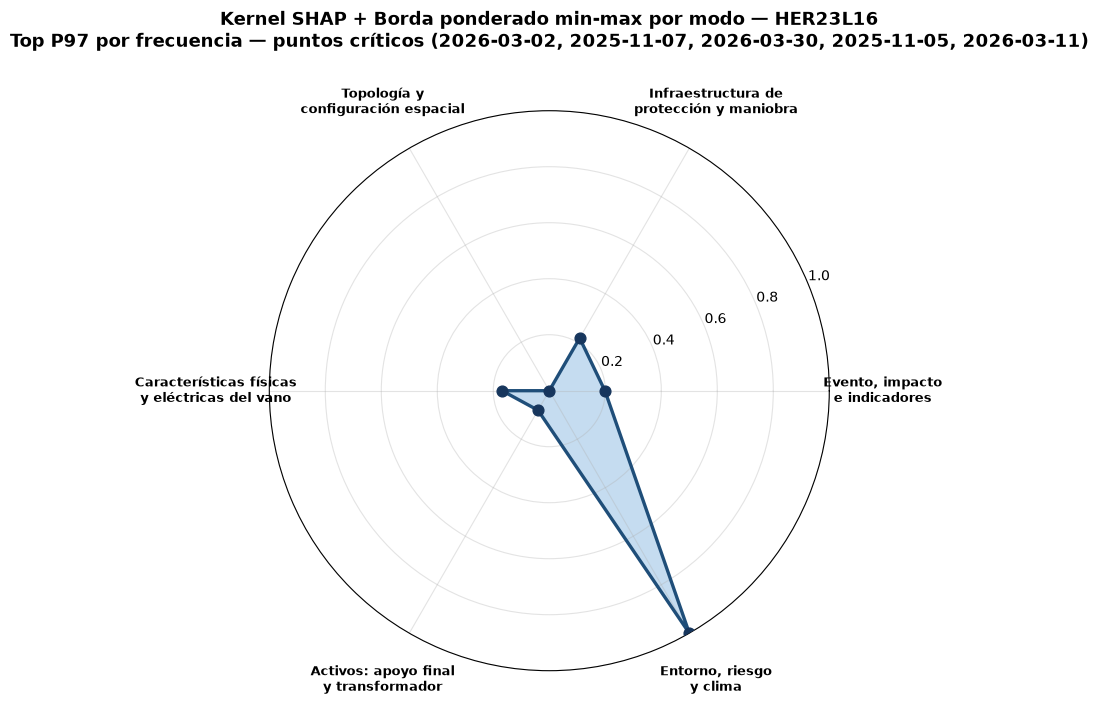

Grafo interactivo guardado en: /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/mgcecdl-results/interactive_graphs/top_frecuencia_fechas.html


In [27]:
base_fechas_inf = base_inf[base_inf["_FECHA_DIA"].isin(FECHAS_INTERES)].copy()
if base_fechas_inf.empty:
    raise ValueError(f"No hay eventos de inferencia para las fechas críticas: {FECHAS_INTERES}")

tabla_fechas_inf = agrupar_por_vano(base_fechas_inf)
fechas_label = ", ".join(FECHAS_INTERES)

# Gravedad en puntos críticos
tabla_top_fechas_uiti, threshold_uiti_fechas = seleccionar_vanos_por_percentil(
    tabla_fechas_inf,
    "UITI_VANO_PROM",
    TOP_N_VANOS,
)
ids_top_fechas_uiti = tabla_top_fechas_uiti["FID_VANO"].tolist()
base_top_fechas_uiti = base_fechas_inf[base_fechas_inf["FID_VANO"].isin(ids_top_fechas_uiti)].copy()

print(
    f"{TOP_VANOS_LABEL} UITI_VANO puntos críticos: umbral >= {threshold_uiti_fechas:.3f} | "
    f"vanos seleccionados: {len(tabla_top_fechas_uiti)}"
)

resultado_top_fechas_uiti = ejecutar_escenario_inferencia(
    key="top_uiti_puntos_criticos",
    nombre=f"Top {TOP_VANOS_LABEL} por UITI_VANO — puntos críticos ({fechas_label})",
    criterio=f"filtrar fechas críticas y seleccionar vanos con UITI_VANO_PROM >= percentil {TOP_N_VANOS}",
    tabla_top=tabla_top_fechas_uiti,
    eventos_escenario=base_top_fechas_uiti,
    graph_output_name="top_uiti_fechas.html",
    fechas_interes=FECHAS_INTERES,
)

# Número de eventos en puntos críticos
tabla_top_fechas_frecuencia, threshold_frecuencia_fechas = seleccionar_vanos_por_percentil(
    tabla_fechas_inf,
    "N_APARICIONES",
    TOP_N_VANOS,
)
ids_top_fechas_frecuencia = tabla_top_fechas_frecuencia["FID_VANO"].tolist()
base_top_fechas_frecuencia = base_fechas_inf[base_fechas_inf["FID_VANO"].isin(ids_top_fechas_frecuencia)].copy()

overlap_fechas = len(set(ids_top_fechas_uiti).intersection(ids_top_fechas_frecuencia))
print(
    f"{TOP_VANOS_LABEL} frecuencia puntos críticos: umbral >= {threshold_frecuencia_fechas:.3f} | "
    f"vanos seleccionados: {len(tabla_top_fechas_frecuencia)} | "
    f"solapamiento UITI/frecuencia: {overlap_fechas}"
)

resultado_top_fechas_frecuencia = ejecutar_escenario_inferencia(
    key="top_frecuencia_puntos_criticos",
    nombre=f"Top {TOP_VANOS_LABEL} por frecuencia — puntos críticos ({fechas_label})",
    criterio=f"filtrar fechas críticas y seleccionar vanos con N_APARICIONES >= percentil {TOP_N_VANOS}; UITI_VANO_PROM solo ordena empates",
    tabla_top=tabla_top_fechas_frecuencia,
    eventos_escenario=base_top_fechas_frecuencia,
    graph_output_name="top_frecuencia_fechas.html",
    fechas_interes=FECHAS_INTERES,
)


### 8.7 Agente de inferencias — discusión estructurada y grafos para HTML

In [28]:
inference_context_package = construir_contexto_inferencia(
    circuito_interes=CIRCUITO_INTERES,
    fecha_inicio=FECHA_INICIO,
    fecha_fin=FECHA_FIN,
    fechas_interes=FECHAS_INTERES,
    top_n_vanos=TOP_N_VANOS,
    top_vanos_percentile=TOP_N_VANOS,
    top_k_vars=TOP_K_VARS,
    filtro_uiti_max=FILTRO_UITI_MAX,
    ventana_climatica_horas=VENTANA_CLIMATICA_HORAS,
    features=features,
    base=base_inf,
    escenarios=[resultado["contexto"] for resultado in inference_results.values()],
    modelo=type(modelo_inferencia).__name__,
    estimated_graph_rbf_sigma=GRAFO_ESTIMADO_RBF_SIGMA,
)

# El agente base también recibe la síntesis de inferencia y las rutas HTML de grafos.
context_package["inference_context"] = inference_context_package

inference_context_path = save_json_artifact(
    inference_context_package,
    OUTPUT_DIR / f"inference_structured_context_{timestamp}.json",
)

missing_inference_skills = verify_required_skills(profile="inferencia")
if missing_inference_skills:
    raise FileNotFoundError(f"Missing required inference LLM skills: {missing_inference_skills}")

inference_skill_bundle = assemble_skill_bundle(profile="inferencia")
inference_prompt = construir_prompt_inferencia(inference_context_package, inference_skill_bundle)
inference_prompt_path = save_prompt_artifact(inference_prompt, OUTPUT_DIR / f"inference_llm_prompt_{timestamp}.md")

print(f"Inference context saved: {inference_context_path}")
print(f"Inference prompt saved : {inference_prompt_path}")
print(f"Inference skills loaded: {list_available_skills(profile='inferencia')}")
print("Grafos entregados al agente:")
for graph_info in inference_context_package["graph_html_paths"]:
    print(f"- {graph_info['escenario']}: {graph_info['path']}")

Inference context saved: /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/interpretability/artifacts/inference_structured_context_20260701T154649Z.json
Inference prompt saved : /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/interpretability/artifacts/inference_llm_prompt_20260701T154649Z.md
Inference skills loaded: ['01_structured_context_builder.md', '02_circuit_scenario_interpreter.md', '03_uiti_vano_behavior_explainer.md', '04_graph_connectivity_guardrails.md', '05_llm_output_validator.md', '06_inference_output_contract.md']
Grafos entregados al agente:
- Top P97 por UITI_VANO — período completo: /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/mgcecdl-results/interactive_graphs/top_uiti_periodo.html
- Top P97 por frecuencia — período completo: /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/mgcecdl-results/interactive_graphs/top_frecuencia_periodo.html
- Top P97 por UITI_VANO — puntos críticos (2

### 8.8 Llamada y validación del agente de inferencia

In [29]:
inference_validation_data = None
last_inference_validation = None
last_inference_llm_result = None
scenario_names = [item["nombre"] for item in inference_context_package.get("escenarios", []) if item.get("nombre")]
minimal_inference_prompt = f"""
Eres un agente de interpretacion de inferencia MGCECDL para CHEC.
Devuelve SOLO JSON valido, sin markdown, sin etiquetas <think> y sin texto adicional.

Debes incluir exactamente estos escenarios, con el mismo nombre:
{json.dumps(scenario_names, ensure_ascii=False, indent=2)}

Contexto minimo:
{json.dumps({
    "contexto": inference_context_package.get("contexto", {}),
    "graph_html_paths": inference_context_package.get("graph_html_paths", []),
    "escenarios": [
        {
            "nombre": item.get("nombre"),
            "criterio": item.get("criterio"),
            "n_vanos_efectivo": item.get("n_vanos_efectivo"),
            "n_eventos": item.get("n_eventos"),
            "top_variables": item.get("top_variables", [])[:3],
            "modos": item.get("modos", [])[:3],
        }
        for item in inference_context_package.get("escenarios", [])
    ],
}, ensure_ascii=False, indent=2)}

Forma exacta:
{{
  "contexto": {{"circuito": "...", "periodo": {{"inicio": "...", "fin": "..."}}, "modelo": "..."}},
  "entregables": {{"grafos_html": [{{"escenario": "...", "path": "..."}}]}},
  "escenarios": [{{"nombre": "...", "interpretacion": "Maximo dos frases."}}],
  "discusion_grafos": [{{"seccion": "periodo_completo", "lectura": "Maximo tres frases sobre asociaciones relativas de los grafos del periodo completo, sin causalidad."}}, {{"seccion": "puntos_criticos", "lectura": "Maximo tres frases sobre asociaciones relativas de los grafos de puntos criticos, sin causalidad."}}],
  "coherencia_grafo_modelo": ["..."],
  "hallazgos": ["..."],
  "limitaciones": ["..."],
  "inferencias_predictivas": [{{"horizonte": "periodo analizado", "riesgo": "...", "justificacion_modelo": "..."}}]
}}
"""
inference_prompt_attempts = [inference_prompt]

for attempt_idx, current_inference_prompt in enumerate(inference_prompt_attempts, start=1):
    inference_llm_result = call_llm(
        current_inference_prompt,
        provider=LLM_PROVIDER,
        model=LLM_MODEL,
        call_enabled=CALL_LLM,
        max_output_tokens=LLM_MAX_OUTPUT_TOKENS,
        display_progress=True,
        display_content=False,
    )
    last_inference_llm_result = inference_llm_result
    print(f"Intento agente de inferencia {attempt_idx}: {inference_llm_result.message}")

    if not inference_llm_result.output_text:
        break

    inference_validation = validar_respuesta_inferencia(inference_llm_result.output_text, inference_context_package)
    last_inference_validation = inference_validation
    if inference_validation["ok"]:
        inference_validation_data = inference_validation["data"]
        inference_analysis_path = save_json_artifact(
            inference_validation_data,
            OUTPUT_DIR / f"inference_llm_analysis_{timestamp}.json",
        )
        print(f"Inference LLM analysis saved: {inference_analysis_path}")
        break

    raw_path, errors_path = save_invalid_output(
        inference_llm_result.output_text,
        inference_validation["errors"],
        OUTPUT_DIR,
        f"inference_attempt_{attempt_idx}_{timestamp}",
    )
    print("La salida del agente de inferencias no validó; se guardó para revisión.")
    print(f"Raw: {raw_path}")
    print(f"Errors: {errors_path}")

    if attempt_idx == 1:
        repair_prompt = f"""
{inference_prompt}

---

La respuesta anterior NO cumplió el contrato JSON o las reglas de validación.
Errores detectados:
{json.dumps(inference_validation["errors"], ensure_ascii=False, indent=2)}

Vuelve a responder desde cero con SOLO JSON válido, sin markdown, sin etiquetas <think>,
sin texto adicional y usando exactamente todos los escenarios de contexto.escenarios con sus mismos nombres.
Incluye discusion_grafos con una lectura para periodo_completo y otra para puntos_criticos cuando existan graph_html_paths de ambas secciones.
No copies arreglos largos del contexto; por escenario devuelve solo nombre e interpretacion.
"""
        inference_prompt_attempts.append(repair_prompt)
    elif attempt_idx == 2:
        inference_prompt_attempts.append(minimal_inference_prompt)

if inference_validation_data is None:
    message = "El agente de inferencias no produjo un JSON válido. No se generará el HTML con análisis de inferencia."
    if last_inference_validation is not None:
        message += f" Últimos errores: {last_inference_validation['errors']}"
    elif last_inference_llm_result is not None:
        message += f" Último estado: {last_inference_llm_result.message}"
    raise RuntimeError(message)


Intento agente de inferencia 2: LLM call completed successfully. finish_reason=stop
Inference LLM analysis saved: /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/interpretability/artifacts/inference_llm_analysis_20260701T154649Z.json


## 9. Save artifacts

In [30]:
context_path = save_json_artifact(context_package, OUTPUT_DIR / f"structured_context_{timestamp}.json")
critical_csv_path = OUTPUT_DIR / f"critical_points_{timestamp}.csv"
critical_points_frame(critical_points).to_csv(critical_csv_path, index=False)
plot_path = save_uiti_vano_plot(
    daily_df,
    critical_points,
    selected_circuitos=selected_circuitos_effective,
    start_date=start_effective,
    end_date=end_effective,
    output_path=OUTPUT_DIR / f"uiti_vano_timeseries_{timestamp}.png",
)
print(context_path)
print(critical_csv_path)
print(plot_path)

/Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/interpretability/artifacts/structured_context_20260701T154649Z.json
/Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/interpretability/artifacts/critical_points_20260701T154649Z.csv
/Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/interpretability/artifacts/uiti_vano_timeseries_20260701T154649Z.png


## 10. LLM skills, contracts, and validation

In [31]:
# El agente base usa la misma configuración de proveedor/modelo que el agente de inferencias.
# No se hace verificación previa ni descarga de modelos en esta celda: `call_llm` usará
# el proveedor configurado y reportará de forma clara si no hay credenciales o servicio.
print(f"CALL_LLM   : {CALL_LLM}")
print(f"LLM_PROVIDER: {LLM_PROVIDER}")
print(f"LLM_MODEL   : {LLM_MODEL}")
print(f"LLM_MAX_OUT : {LLM_MAX_OUTPUT_TOKENS}")
print(f"LLM_BASE_OUT: {LLM_BASE_MAX_OUTPUT_TOKENS}")
print(f"LLM_EXPERT_OUT: {LLM_EXPERT_ALIGNMENT_MAX_OUTPUT_TOKENS}")


CALL_LLM   : True
LLM_PROVIDER: openai
LLM_MODEL   : gpt-4.1-mini
LLM_MAX_OUT : 32768
LLM_BASE_OUT: 65536
LLM_EXPERT_OUT: 65536


In [34]:
missing_skills = verify_required_skills()
if missing_skills:
    raise FileNotFoundError(f"Missing required LLM skills: {missing_skills}")
skills = list_available_skills()
skill_bundle = assemble_skill_bundle()
output_schema = load_output_schema()
prompt = render_prompt(
    context_json=json.dumps(context_package, ensure_ascii=False),
    output_schema_json=json.dumps(output_schema, ensure_ascii=False),
    prompt_version=PROMPT_VERSION,
    skill_bundle=skill_bundle,
)
prompt_path = save_prompt_artifact(prompt, OUTPUT_DIR / f"llm_prompt_{timestamp}.md")
print(f"Loaded skills: {skills}")
print(f"Prompt saved: {prompt_path}")
print(f"Skill bundle characters: {len(skill_bundle)}")

Loaded skills: ['01_structured_context_builder.md', '02_critical_point_interpreter.md', '03_uiti_vano_behavior_explainer.md', '04_domain_grounding_guardrails.md', '05_llm_output_validator.md', '06_base_repair.md', '07_base_output_contract.md']
Prompt saved: /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/interpretability/artifacts/llm_prompt_20260701T154649Z.md
Skill bundle characters: 14133


In [35]:
validation_data = None
last_base_llm_result = None
last_base_validation = None

base_prompt_attempts = [prompt]
for attempt_idx, current_prompt in enumerate(base_prompt_attempts, start=1):
    llm_result = call_llm(
        current_prompt,
        provider=LLM_PROVIDER,
        model=LLM_MODEL,
        call_enabled=CALL_LLM,
        max_output_tokens=LLM_BASE_MAX_OUTPUT_TOKENS,
        display_progress=True,
    display_content=False,
    )
    last_base_llm_result = llm_result
    print(f"Intento agente base {attempt_idx}: {llm_result.message}")

    if not llm_result.output_text:
        continue

    validation = validate_llm_response(llm_result.output_text, context_package, output_schema)
    last_base_validation = validation
    if validation.ok and validation.data:
        validation_data = validation.data
        analysis_path = save_json_artifact(
            validation_data,
            OUTPUT_DIR / f"llm_analysis_{timestamp}.json",
        )
        print(f"LLM analysis JSON saved: {analysis_path}")
        break

    raw_path, errors_path = save_invalid_output(
        llm_result.output_text,
        validation.errors,
        OUTPUT_DIR,
        f"base_attempt_{attempt_idx}_{timestamp}",
    )
    print("La salida del agente base no validó; se guardó para revisión.")
    print(f"Raw: {raw_path}")
    print(f"Errors: {errors_path}")

    if attempt_idx == 1:
        repair_prompt = render_base_repair_prompt(
            context_package,
            prompt_version=PROMPT_VERSION,
            top_vanos_percentile=TOP_VANOS_PERCENTILE,
            max_critical_points=MAX_CRITICAL_POINTS,
        ) + "\n\nErrores detectados en el intento anterior:\n" + json.dumps(validation.errors, ensure_ascii=False, indent=2)
        base_prompt_attempts.append(repair_prompt)
    elif attempt_idx == 2:
        expanded_repair_prompt = render_base_repair_prompt(
            context_package,
            prompt_version=PROMPT_VERSION,
            top_vanos_percentile=TOP_VANOS_PERCENTILE,
            max_critical_points=MAX_CRITICAL_POINTS,
        ) + "\n\nEl intento anterior siguió inválido. Corrige solo el JSON final y ciérralo completamente. Errores:\n" + json.dumps(validation.errors, ensure_ascii=False, indent=2)
        print("Reintentando agente base con mayor presupuesto de salida.")
        base_prompt_attempts.append(expanded_repair_prompt)

if validation_data is None:
    message = "El agente base no produjo un JSON válido. No se generará el HTML."
    if last_base_validation is not None:
        message += f" Últimos errores: {last_base_validation.errors}"
    elif last_base_llm_result is not None:
        message += f" Último estado: {last_base_llm_result.message}"
    raise RuntimeError(message)


Intento agente base 1: LLM call failed: Error code: 400 - {'error': {'message': 'max_tokens is too large: 65536. This model supports at most 32768 completion tokens, whereas you provided 65536.', 'type': 'invalid_request_error', 'param': 'max_tokens', 'code': 'invalid_value'}}


RuntimeError: El agente base no produjo un JSON válido. No se generará el HTML. Último estado: LLM call failed: Error code: 400 - {'error': {'message': 'max_tokens is too large: 65536. This model supports at most 32768 completion tokens, whereas you provided 65536.', 'type': 'invalid_request_error', 'param': 'max_tokens', 'code': 'invalid_value'}}

## 10.1 LLM3: comparación con reportes expertos


In [ ]:
expert_alignment_validation_data = None
last_expert_alignment_validation = None
last_expert_alignment_llm_result = None
top_pdf_matches = []
expert_alignment_context = None
expert_alignment_context_path = None
expert_alignment_matches_path = None

pdf_discussions_df, pdf_discussion_warnings = cargar_discussiones_pdf_excel(PDF_DISCUSSIONS_EXCEL_PATH)
for warning in pdf_discussion_warnings:
    print(f"Advertencia LLM3: {warning}")

if pdf_discussions_df.empty:
    skipped_path = save_json_artifact(
        {
            "status": "skipped",
            "reason": "pdf_discussions_excel_missing_or_empty",
            "excel_path": str(PDF_DISCUSSIONS_EXCEL_PATH),
            "warnings": pdf_discussion_warnings,
        },
        OUTPUT_DIR / f"expert_alignment_skipped_{timestamp}.json",
    )
    print(f"LLM3 omitido; artefacto guardado: {skipped_path}")
else:
    fechas_informe = extraer_fechas_informe(
        validation_data=validation_data,
        inference_validation_data=inference_validation_data,
        context_package=context_package,
        inference_context_package=inference_context_package,
        critical_points=critical_points,
        fecha_inicio=globals().get("FECHA_INICIO", start_effective),
        fecha_fin=globals().get("FECHA_FIN", end_effective),
        fechas_interes=globals().get("FECHAS_INTERES", None),
    )
    top_pdf_matches = seleccionar_top_coincidencias_temporales(
        fechas_informe=fechas_informe,
        pdf_df=pdf_discussions_df,
        circuito_interes=globals().get("CIRCUITO_INTERES", selected_circuitos_effective[0] if selected_circuitos_effective else None),
        top_k=min(TOP_K_PDF_DATE_MATCHES, MAX_EXPERT_ROWS_FOR_LLM3),
    )

    expert_alignment_matches_path = guardar_tabla_coincidencias_pdf(
        top_pdf_matches,
        OUTPUT_DIR / f"expert_alignment_pdf_matches_{timestamp}.xlsx",
    )
    print(f"Filas expertas candidatas guardadas: {expert_alignment_matches_path}")

    if not top_pdf_matches:
        skipped_path = save_json_artifact(
            {
                "status": "skipped",
                "reason": "no_temporal_pdf_matches",
                "excel_path": str(PDF_DISCUSSIONS_EXCEL_PATH),
                "n_pdf_rows": int(len(pdf_discussions_df)),
                "n_fechas_informe": int(len(fechas_informe)),
            },
            OUTPUT_DIR / f"expert_alignment_skipped_{timestamp}.json",
        )
        print(f"LLM3 omitido; no hubo coincidencias temporales comparables. Artefacto: {skipped_path}")
    else:
        expert_alignment_context = construir_contexto_expert_alignment(
            circuito=globals().get("CIRCUITO_INTERES", selected_circuitos_effective[0] if selected_circuitos_effective else ""),
            periodo_inicio=globals().get("FECHA_INICIO", start_effective),
            periodo_fin=globals().get("FECHA_FIN", end_effective),
            fechas_informe=fechas_informe,
            validation_data=validation_data,
            inference_validation_data=inference_validation_data,
            pdf_expert_matches=top_pdf_matches,
            inference_context_package=globals().get("inference_context_package", None),
            variables_modelo_predictivo=globals().get("features", []),
        )
        expert_alignment_context_path = save_json_artifact(
            expert_alignment_context,
            OUTPUT_DIR / f"expert_alignment_context_{timestamp}.json",
        )

        missing_expert_skills = verify_required_skills(profile="expert_alignment")
        if missing_expert_skills:
            raise FileNotFoundError(f"Missing required expert-alignment LLM skills: {missing_expert_skills}")

        expert_alignment_skill_bundle = assemble_skill_bundle(profile="expert_alignment")
        expert_alignment_prompt = construir_prompt_expert_alignment(expert_alignment_context, expert_alignment_skill_bundle)
        expert_alignment_prompt_path = save_prompt_artifact(
            expert_alignment_prompt,
            OUTPUT_DIR / f"expert_alignment_prompt_{timestamp}.md",
        )
        print(f"Expert alignment context saved: {expert_alignment_context_path}")
        print(f"Expert alignment prompt saved : {expert_alignment_prompt_path}")
        print(f"Expert alignment skills loaded: {list_available_skills(profile='expert_alignment')}")

        expert_alignment_prompt_attempts = [expert_alignment_prompt]
        for attempt_idx, current_prompt in enumerate(expert_alignment_prompt_attempts, start=1):
            expert_alignment_llm_result = call_llm(
                current_prompt,
                provider=LLM_PROVIDER,
                model=LLM_MODEL,
                call_enabled=CALL_LLM3,
                max_output_tokens=LLM_EXPERT_ALIGNMENT_MAX_OUTPUT_TOKENS,
                display_progress=True,
                display_content=False,
            )
            last_expert_alignment_llm_result = expert_alignment_llm_result
            print(f"Intento agente expert_alignment {attempt_idx}: {expert_alignment_llm_result.message}")

            if not expert_alignment_llm_result.output_text:
                break

            expert_alignment_validation = validar_respuesta_expert_alignment(
                expert_alignment_llm_result.output_text,
                expert_alignment_context,
            )
            last_expert_alignment_validation = expert_alignment_validation
            if expert_alignment_validation["ok"]:
                expert_alignment_validation_data = expert_alignment_validation["data"]
                expert_alignment_analysis_path = save_json_artifact(
                    expert_alignment_validation_data,
                    OUTPUT_DIR / f"expert_alignment_analysis_{timestamp}.json",
                )
                print(f"Expert alignment analysis saved: {expert_alignment_analysis_path}")
                break

            raw_path, errors_path = save_invalid_output(
                expert_alignment_llm_result.output_text,
                expert_alignment_validation["errors"],
                OUTPUT_DIR,
                f"expert_alignment_attempt_{attempt_idx}_{timestamp}",
            )
            print("La salida del agente expert_alignment no validó; se guardó para revisión.")
            print(f"Raw: {raw_path}")
            print(f"Errors: {errors_path}")

            if attempt_idx == 1:
                repair_prompt = f"""
{expert_alignment_prompt}

---

La respuesta anterior NO cumplió el contrato JSON o las reglas de validación.
Errores detectados:
{json.dumps(expert_alignment_validation["errors"], ensure_ascii=False, indent=2)}

Vuelve a responder desde cero con SOLO JSON válido, sin markdown, sin etiquetas <think> y sin texto adicional.
No inventes fechas, variables ni evidencia PDF. Usa únicamente las fuentes incluidas en el contexto.
Mantén el mismo nivel de análisis y asegúrate de cerrar completamente el objeto JSON.
"""
                expert_alignment_prompt_attempts.append(repair_prompt)

if expert_alignment_validation_data is None:
    print("Advertencia LLM3: no se generó comparación experta válida; el HTML continuará sin esa sección.")


Intento agente expert_alignment 1: LLM call completed successfully. finish_reason=stop
Expert alignment analysis saved: /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/interpretability/artifacts/expert_alignment_analysis_20260701T152125Z.json


# 11 Html results visualization

In [ ]:
from chec_local_interpreter.plotting import render_llm_analysis
from chec_local_interpreter.web_export import export_latest_interpretability_report

if not globals().get("validation_data"):
    raise RuntimeError("validation_data está vacío; no se genera HTML sin análisis base válido.")

html_path = render_llm_analysis(
    validation_data=validation_data,
    raw_df=raw_df,
    daily_df=daily_df,
    critical_points=critical_points,
    selected_circuitos=selected_circuitos_effective,
    start_date=start_effective,
    end_date=end_effective,
    llm_model=LLM_MODEL,
    llm_provider=LLM_PROVIDER,
    inference_results=globals().get("inference_results", {}),
    inference_analysis=globals().get("inference_validation_data", None),
    expert_alignment_analysis=globals().get("expert_alignment_validation_data", None),
    expert_alignment_matches=globals().get("top_pdf_matches", []),
    output_dir=ROOT / "reports" / "interpretability" / "html",
)
site_report_path = export_latest_interpretability_report(html_path)
print(
    f"HTML Analysis Report guardado en reports/interpretability/html: "
    f"{html_path}"
)
print(f">>> Reporte web actualizado: {site_report_path.name}")


✅ **Reporte generado y guardado exitosamente:** [/Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/interpretability/html/DON23L14_20251101_20260430_20260701T102614.html](/Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/interpretability/html/DON23L14_20251101_20260430_20260701T102614.html)

HTML Analysis Report guardado en reports/interpretability/html: /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/interpretability/html/DON23L14_20251101_20260430_20260701T102614.html
>>> Reporte web actualizado: latest_interpretability_report.html
